# Credit Card Fraud Detection — End-to-End Pipeline

This notebook presents an end-to-end machine learning workflow for detecting fraudulent credit card transactions. The project includes data preparation, baseline logistic regression, model evaluation, class imbalance handling, and threshold tuning to improve fraud detection performance.

## 1. Load Data

The dataset is loaded from the local `data/` folder. It contains anonymized transaction features (`V1` to `V28`), along with `Time`, `Amount`, and the target variable `Class`, where:

- `0` = non-fraudulent transaction
- `1` = fraudulent transaction

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/creditcard.csv")

# Preview first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Understand the Dataset

Before training a model, it is important to inspect the dataset structure. This includes checking:

- the number of rows and columns
- variable names and types
- whether missing values are present
- summary statistics of numerical variables

This step helps confirm that the dataset is suitable for machine learning.

In [2]:
# Dataset shape
df.shape

# Column names
df.columns

# General information and data types
df.info()

# Missing values per column
df.isnull().sum()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


The dataset contains anonymized numerical features (`V1` to `V28`), in addition to `Time`, `Amount`, and the target variable `Class`. No missing values were detected, which simplifies preprocessing.

## 3. Check Target Distribution

Fraud detection is typically a highly imbalanced classification problem, with fraudulent transactions representing only a very small fraction of all transactions.

It is therefore essential to check the class distribution before training the model, since standard accuracy can be misleading in this context.

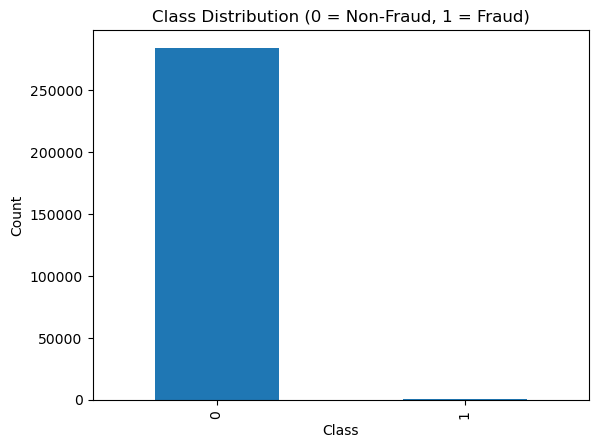

In [3]:
# Number of observations in each class
df["Class"].value_counts()

# Class proportions
df["Class"].value_counts(normalize=True)

import matplotlib.pyplot as plt

# Visualize class imbalance
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is strongly imbalanced, with non-fraudulent transactions largely outnumbering fraudulent ones. This means that evaluation metrics such as precision, recall, and F1-score will be more informative than accuracy alone.

## 4. Data Cleaning

The dataset does not contain missing values, but duplicate rows should still be checked. Removing duplicates is important because repeated observations can bias the model and artificially improve performance.

In [4]:
# Count duplicate rows
df.duplicated().sum()

# Remove duplicate rows
df = df.drop_duplicates()

# Confirm duplicates were removed
df.duplicated().sum()

# Check updated dataset shape
df.shape

(283726, 31)

Duplicate rows were detected and removed. This reduces the risk of biased learning and helps ensure that model evaluation reflects true generalization rather than repeated examples.

## 5. Feature / Target Split

To prepare the dataset for supervised learning, the target variable is separated from the input features.

- `X` contains all predictor variables
- `y` contains the target variable `Class`

In [5]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Check dimensions
X.shape, y.shape

((283726, 30), (283726,))

The input matrix `X` contains all transaction features, while `y` stores the fraud label to be predicted by the model.

## 6. Train / Test Split

The dataset is divided into training and testing sets. The training set is used to fit the model, while the testing set is used to evaluate performance on unseen data.

Stratification is applied to preserve the original class imbalance in both sets.

In [6]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check train and test dimensions
X_train.shape, X_test.shape

# Verify class proportions are preserved
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Class
 0    0.998335
 1    0.001665
 Name: proportion, dtype: float64,
 Class
 0    0.998326
 1    0.001674
 Name: proportion, dtype: float64)

The dataset was split into training and testing sets using an 80/20 ratio. Stratification ensured that the proportion of fraud and non-fraud cases remained consistent across both sets.

## 7. Feature Scaling

Feature scaling is applied before logistic regression to ensure that variables are on a comparable scale.

The scaler is fitted only on the training data and then applied to the test data to prevent data leakage.

In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test = scaler.transform(X_test)

Standardization was applied to the feature set. This is particularly important for logistic regression, since variables with very different scales can influence the optimization process disproportionately.

## 8. Logistic Regression Model

A baseline logistic regression model is trained to classify transactions as fraudulent or non-fraudulent.

In addition to binary predictions, predicted probabilities are also generated. These probabilities will later be used for threshold tuning.

In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize baseline logistic regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict class labels
y_pred = model.predict(X_test)

# Predict probabilities for class 1 (fraud)
y_proba = model.predict_proba(X_test)[:, 1]

This baseline model uses the default decision threshold of 0.5. Transactions with a predicted fraud probability greater than or equal to 0.5 are classified as fraudulent.

## 9. Model Evaluation

The baseline model is evaluated using a confusion matrix and a classification report.

In fraud detection, recall is particularly important because failing to detect fraudulent transactions can be more costly than raising false alarms.

Confusion Matrix:
[[56641    10]
 [   40    55]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9560466717268892


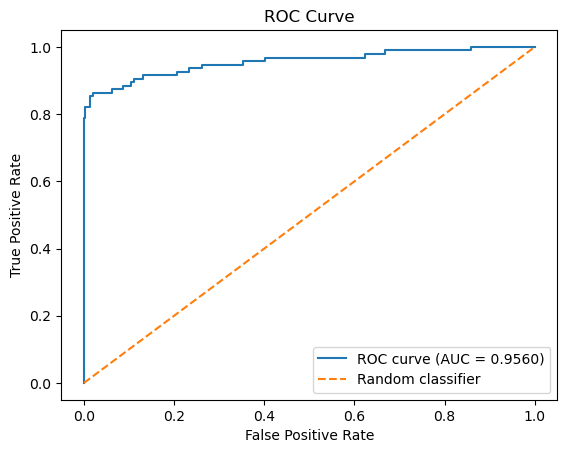

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import roc_auc_score, roc_curve

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Although the model may achieve high overall performance, the minority fraud class requires specific attention. Metrics such as recall and ROC-AUC are more informative than accuracy in this imbalanced setting.

The ROC curve indicates that the model performs substantially better than random guessing and has a strong ability to distinguish fraudulent from non-fraudulent transactions.

## 10. Handle Class Imbalance

Because fraudulent transactions are rare, a second logistic regression model is trained using class weighting.

This approach gives more importance to the minority class during training and is intended to improve fraud detection recall, even if this increases the number of false positives.

In [11]:
# Initialize logistic regression model with class balancing
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train balanced model
model_balanced.fit(X_train, y_train)

# Predict class labels
y_pred_bal = model_balanced.predict(X_test)

print("Confusion Matrix (Balanced Model):")
print(confusion_matrix(y_test, y_pred_bal))

print("\nClassification Report (Balanced Model):")
print(classification_report(y_test, y_pred_bal))

Confusion Matrix (Balanced Model):
[[55262  1389]
 [   12    83]]

Classification Report (Balanced Model):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



To address class imbalance, a second logistic regression model was trained using class weighting. This approach improved the detection of fraudulent transactions by increasing recall, but it also introduced more false positives.

This trade-off is common in fraud detection, where missing fraudulent cases can be more critical than raising false alarms.

## 11. Threshold Tuning

The default classification threshold of 0.5 is not always optimal for imbalanced problems.

Since the model outputs probabilities, different thresholds can be tested to better balance precision and recall. Lower thresholds generally increase fraud detection recall, while higher thresholds tend to reduce false positives.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Test several probability thresholds
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print("Threshold | Precision | Recall | F1-score")
print("----------------------------------------")

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"{t:.1f}      | {precision:.3f}     | {recall:.3f} | {f1:.3f}")

Threshold | Precision | Recall | F1-score
----------------------------------------
0.1      | 0.833     | 0.737 | 0.782
0.2      | 0.833     | 0.684 | 0.751
0.3      | 0.836     | 0.642 | 0.726
0.4      | 0.853     | 0.611 | 0.712
0.5      | 0.846     | 0.579 | 0.688


Threshold tuning showed that the default threshold of 0.5 was not optimal for this fraud detection task. Lowering the threshold improved recall and produced a better balance between detecting fraud and limiting false positives.

This highlights the importance of treating the classification threshold as a decision parameter rather than relying blindly on the model default.

## 12. Final Model with Optimized Threshold

Based on the threshold comparison, the best threshold is selected and applied to the predicted probabilities.

This final step does not retrain the model. Instead, it changes the decision rule used to convert predicted probabilities into fraud / non-fraud labels.

In [13]:
# Set optimized threshold
best_threshold = 0.1

# Apply optimized threshold to predicted probabilities
y_pred_final = (y_proba >= best_threshold).astype(int)

print("Final Model (Optimized Threshold)")
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Final Model (Optimized Threshold)
[[56637    14]
 [   25    70]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.74      0.78        95

    accuracy                           1.00     56746
   macro avg       0.92      0.87      0.89     56746
weighted avg       1.00      1.00      1.00     56746



Although the balanced model achieved higher recall and missed fewer fraudulent transactions, it produced a very large number of false positives, resulting in extremely low precision.

After threshold tuning, the model missed slightly more fraudulent transactions, but achieved a substantial improvement in precision. This makes the model more practical, as the majority of flagged transactions are truly fraudulent.

This highlights a key trade-off in fraud detection: maximizing recall can lead to excessive false alarms, while a more balanced approach can provide better real-world usability.

## Conclusion

This project developed an end-to-end fraud detection pipeline using logistic regression. The analysis showed that:

- the dataset is highly imbalanced
- a baseline logistic regression model provides strong discrimination ability
- class weighting improves fraud recall but may increase false positives
- threshold tuning is an effective way to optimize the trade-off between recall and precision

Overall, this project illustrates how machine learning for fraud detection requires not only model training, but also careful handling of imbalance and decision threshold optimization.